In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests
import time
import math
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text

# Character mapping
chars       = sorted(list(set(text)))
vocab_size  = len(chars)
char_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_char = {i: ch for i, ch in enumerate(chars)}

print(f'Corpus length : {len(text):,} characters')
print(f'Vocabulary size: {vocab_size} unique characters')

def make_loaders(sequence_length, batch_size=128, val_split=0.2, seed=42):
    encoded_text = [char_to_int[ch] for ch in text]
    sequences, targets = [], []
    for i in range(len(encoded_text) - sequence_length):
        sequences.append(encoded_text[i : i + sequence_length])
        targets.append(encoded_text[i + sequence_length])

    sequences = torch.tensor(sequences, dtype=torch.long)
    targets   = torch.tensor(targets,   dtype=torch.long)

    class CharDataset(Dataset):
        def __init__(self, seqs, tgts):
            self.sequences = seqs
            self.targets   = tgts
        def __len__(self):  return len(self.targets)
        def __getitem__(self, idx): return self.sequences[idx], self.targets[idx]

    dataset    = CharDataset(sequences, targets)
    train_size = int(len(dataset) * (1 - val_split))
    val_size   = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(seed)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    print(f'  seq_len={sequence_length}: {len(train_ds):,} train | {len(val_ds):,} val samples')
    return train_loader, val_loader

Corpus length : 1,115,394 characters
Vocabulary size: 65 unique characters


In [ ]:
class CharModel(nn.Module):

    def __init__(self, vocab_size, embed_dim=128, hidden_size=256,
                 num_layers=2, model_type='LSTM', dropout=0.3):
        super().__init__()
        self.model_type  = model_type
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        rnn_kwargs = dict(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        if model_type == 'LSTM':
            self.rnn = nn.LSTM(**rnn_kwargs)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(**rnn_kwargs)
        else:
            raise ValueError(f'Unknown model_type: {model_type}')

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        emb    = self.embedding(x)
        out, _ = self.rnn(emb)
        last   = out[:, -1, :]
        return self.fc(self.dropout(last))

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        logits  = model(xb)
        total_loss += criterion(logits, yb).item() * xb.size(0)
        correct    += (logits.argmax(1) == yb).sum().item()
    n = len(loader.dataset)
    avg_loss = total_loss / n
    return avg_loss, correct / n, math.exp(avg_loss)   # loss, accuracy, perplexity


@torch.no_grad()
def measure_inference_time(model, loader, n_batches=20):
    model.eval()
    times = []
    for i, (xb, _) in enumerate(loader):
        if i >= n_batches: break
        xb = xb.to(device)
        torch.cuda.synchronize() if device.type == 'cuda' else None
        t0 = time.perf_counter()
        _ = model(xb)
        torch.cuda.synchronize() if device.type == 'cuda' else None
        times.append((time.perf_counter() - t0) / xb.size(0) * 1000)  # ms/sample
    return float(np.mean(times))


def train_model(model_type, seq_len, embed_dim=128, hidden_size=256,
                num_layers=2, dropout=0.3, epochs=20, lr=1e-3,
                patience=5, save_dir=None):

    train_loader, val_loader = make_loaders(seq_len)

    model     = CharModel(vocab_size, embed_dim=embed_dim, hidden_size=hidden_size,
                          num_layers=num_layers, model_type=model_type,
                          dropout=dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss()

    history          = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_ppl': []}
    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0
    best_epoch       = 0

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        tr_loss                    = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_ppl = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_ppl'].append(val_ppl)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            best_epoch       = epoch
        else:
            patience_counter += 1

        print(f'  [{model_type} | seq={seq_len}] Epoch {epoch:2d} — '
              f'train={tr_loss:.4f}  val={val_loss:.4f}  '
              f'acc={val_acc:.3f}  ppl={val_ppl:.2f}  patience={patience_counter}/{patience}')

        if patience_counter >= patience:
            print(f'  Early stop at epoch {epoch} (best: {best_epoch})')
            break

    elapsed = time.time() - t0
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    infer_ms = measure_inference_time(model, val_loader)

    if save_dir:
        import os; os.makedirs(save_dir, exist_ok=True)
        tag  = f'{model_type}_seq{seq_len}_h{hidden_size}_l{num_layers}'
        path = f'{save_dir}/{tag}.pt'
        torch.save(model.state_dict(), path)
        print(f'  Saved -> {path}')

    return history, elapsed, model.count_parameters(), best_epoch, infer_ms, model

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/HW2_P2_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Models will be saved to: {SAVE_DIR}')

Mounted at /content/drive
Models will be saved to: /content/drive/MyDrive/HW2_P2_models


In [ ]:
BASELINE_CONFIG = dict(embed_dim=128, hidden_size=256, num_layers=2, dropout=0.3,
                       epochs=20, patience=5)

part1_results = {}

for mtype, slen in product(['LSTM', 'GRU'], [20, 30]):
    print(f'\n=== {mtype} | seq_len={slen} ===')
    history, elapsed, n_params, best_ep, infer_ms, model = train_model(
        mtype, slen, save_dir=SAVE_DIR, **BASELINE_CONFIG
    )
    part1_results[(mtype, slen)] = {
        'history' : history,
        'time_s'  : elapsed,
        'params'  : n_params,
        'best_ep' : best_ep,
        'infer_ms': infer_ms,
        'train_loss': history['train_loss'][best_ep - 1],
        'val_loss'  : history['val_loss'][best_ep - 1],
        'val_acc'   : history['val_acc'][best_ep - 1],
        'val_ppl'   : history['val_ppl'][best_ep - 1],
    }
    print(f'  Done: {elapsed:.1f}s | params={n_params:,} | infer={infer_ms:.3f} ms/sample')


=== LSTM | seq_len=20 ===
  seq_len=20: 892,299 train | 223,075 val samples
  [LSTM | seq=20] Epoch  1 — train=1.7977  val=1.5183  acc=0.540  ppl=4.56  patience=0/5
  [LSTM | seq=20] Epoch  2 — train=1.5404  val=1.4323  acc=0.562  ppl=4.19  patience=0/5
  [LSTM | seq=20] Epoch  3 — train=1.4789  val=1.3966  acc=0.571  ppl=4.04  patience=0/5
  [LSTM | seq=20] Epoch  4 — train=1.4466  val=1.3773  acc=0.575  ppl=3.96  patience=0/5
  [LSTM | seq=20] Epoch  5 — train=1.4264  val=1.3623  acc=0.580  ppl=3.91  patience=0/5
  [LSTM | seq=20] Epoch  6 — train=1.4119  val=1.3547  acc=0.582  ppl=3.88  patience=0/5
  [LSTM | seq=20] Epoch  7 — train=1.4017  val=1.3456  acc=0.584  ppl=3.84  patience=0/5
  [LSTM | seq=20] Epoch  8 — train=1.3942  val=1.3398  acc=0.586  ppl=3.82  patience=0/5
  [LSTM | seq=20] Epoch  9 — train=1.3882  val=1.3376  acc=0.586  ppl=3.81  patience=0/5
  [LSTM | seq=20] Epoch 10 — train=1.3829  val=1.3344  acc=0.586  ppl=3.80  patience=0/5
  [LSTM | seq=20] Epoch 11 — trai

In [ ]:
# Part 1 results table
rows = []
for (mtype, slen), r in part1_results.items():
    rows.append({
        'Model'       : mtype,
        'Seq Len'     : slen,
        'Best Epoch'  : r['best_ep'],
        'Train Loss'  : f"{r['train_loss']:.4f}",
        'Val Loss'    : f"{r['val_loss']:.4f}",
        'Val Accuracy': f"{r['val_acc']:.3f}",
        'Perplexity'  : f"{r['val_ppl']:.2f}",
        'Train Time(s)': f"{r['time_s']:.1f}",
        'Infer(ms/samp)': f"{r['infer_ms']:.3f}",
        'Parameters'  : f"{r['params']:,}",
    })
df1 = pd.DataFrame(rows)
print('Part 1 Results')
print(df1.to_string(index=False))
df1

Part 1 Results
Model  Seq Len  Best Epoch Train Loss Val Loss Val Accuracy Perplexity Train Time(s) Infer(ms/samp) Parameters
 LSTM       20          17     1.3656   1.3206        0.590       3.75         728.5          0.011    946,625
 LSTM       30          20     1.3537   1.3120        0.594       3.71         866.4          0.013    946,625
  GRU       20          20     1.5013   1.4086        0.572       4.09         704.8          0.010    716,225
  GRU       30          20     1.5058   1.4144        0.572       4.11         847.5          0.015    716,225


,Model,Seq Len,Best Epoch,Train Loss,Val Loss,Val Accuracy,Perplexity,Train Time(s),Infer(ms/samp),Parameters
0,LSTM,20,17,1.3656,1.3206,0.590,3.75,728.5,0.011,"946,625"
1,LSTM,30,20,1.3537,1.3120,0.594,3.71,866.4,0.013,"946,625"
2,GRU,20,20,1.5013,1.4086,0.572,4.09,704.8,0.010,"716,225"
3,GRU,30,20,1.5058,1.4144,0.572,4.11,847.5,0.015,"716,225"


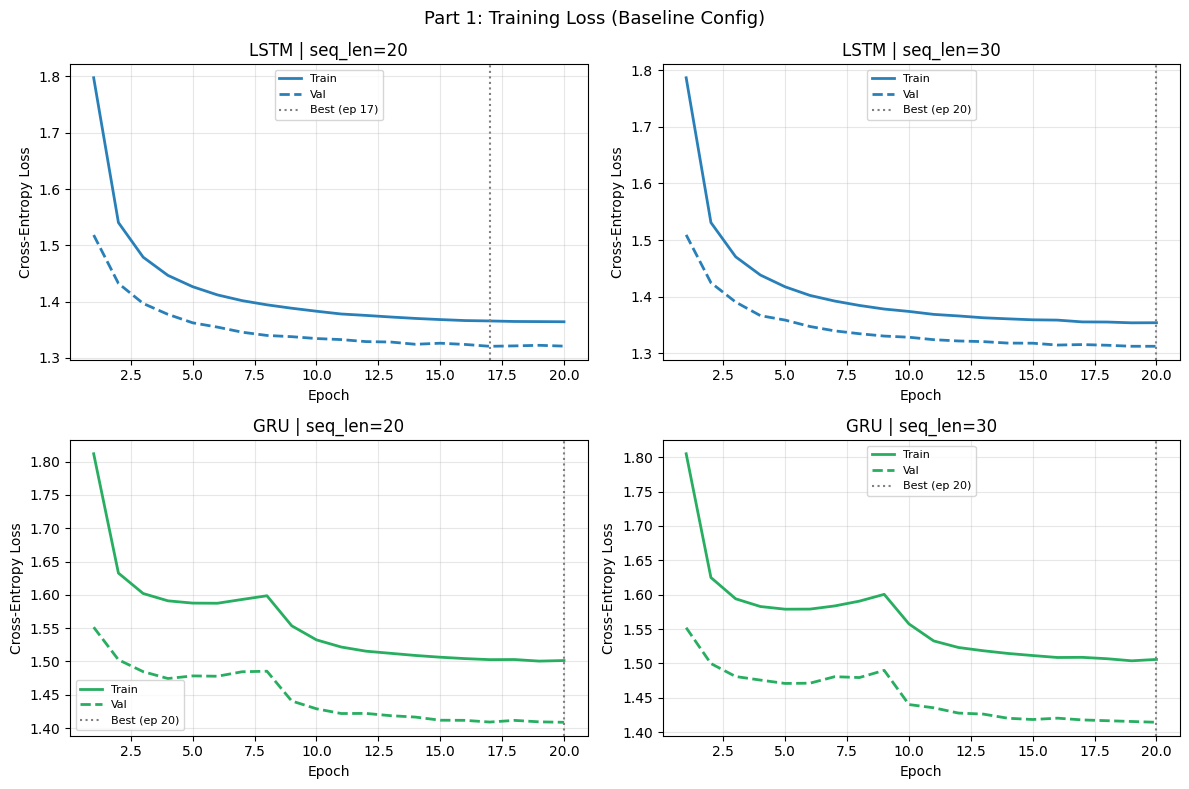

In [ ]:
# Part 1 loss curves
colors = {'LSTM': '#2980b9', 'GRU': '#27ae60'}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Part 1: Training Loss (Baseline Config)', fontsize=13)

for col_idx, slen in enumerate([20, 30]):
    for row_idx, mtype in enumerate(['LSTM', 'GRU']):
        ax  = axes[row_idx][col_idx]
        res = part1_results[(mtype, slen)]
        ep  = range(1, len(res['history']['train_loss']) + 1)
        ax.plot(ep, res['history']['train_loss'], color=colors[mtype], linewidth=2, label='Train')
        ax.plot(ep, res['history']['val_loss'],   color=colors[mtype], linewidth=2, label='Val', linestyle='--')
        ax.axvline(res['best_ep'], color='gray', linestyle=':', linewidth=1.5, label=f"Best (ep {res['best_ep']})")
        ax.set_title(f'{mtype} | seq_len={slen}')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('p2_part1_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
HP_CONFIGS = [
    {'label': 'Small',  'hidden_size': 128, 'num_layers': 1},
    {'label': 'Base',   'hidden_size': 256, 'num_layers': 2},
    {'label': 'Large',  'hidden_size': 512, 'num_layers': 2},
    {'label': 'Deep',   'hidden_size': 256, 'num_layers': 3},
]

HP_SEQ_LEN = 20
part2_results = {}

for cfg in HP_CONFIGS:
    for mtype in ['LSTM', 'GRU']:
        key = (mtype, cfg['label'])
        print(f'\n=== {mtype} | {cfg["label"]} (h={cfg["hidden_size"]}, layers={cfg["num_layers"]}) ===')
        history, elapsed, n_params, best_ep, infer_ms, model = train_model(
            mtype, HP_SEQ_LEN,
            embed_dim=128,
            hidden_size=cfg['hidden_size'],
            num_layers=cfg['num_layers'],
            dropout=0.3,
            epochs=20,
            patience=5,
            save_dir=SAVE_DIR
        )
        part2_results[key] = {
            'history'    : history,
            'config'     : cfg,
            'time_s'     : elapsed,
            'params'     : n_params,
            'best_ep'    : best_ep,
            'infer_ms'   : infer_ms,
            'train_loss' : history['train_loss'][best_ep - 1],
            'val_loss'   : history['val_loss'][best_ep - 1],
            'val_acc'    : history['val_acc'][best_ep - 1],
            'val_ppl'    : history['val_ppl'][best_ep - 1],
        }
        print(f'  Done: {elapsed:.1f}s | params={n_params:,} | infer={infer_ms:.3f} ms/sample')


=== LSTM | Small (h=128, layers=1) ===
  seq_len=20: 892,299 train | 223,075 val samples
  [LSTM | seq=20] Epoch  1 — train=1.9591  val=1.6897  acc=0.499  ppl=5.42  patience=0/5
  [LSTM | seq=20] Epoch  2 — train=1.7240  val=1.6011  acc=0.522  ppl=4.96  patience=0/5
  [LSTM | seq=20] Epoch  3 — train=1.6616  val=1.5589  acc=0.533  ppl=4.75  patience=0/5
  [LSTM | seq=20] Epoch  4 — train=1.6250  val=1.5307  acc=0.540  ppl=4.62  patience=0/5
  [LSTM | seq=20] Epoch  5 — train=1.6010  val=1.5128  acc=0.545  ppl=4.54  patience=0/5
  [LSTM | seq=20] Epoch  6 — train=1.5834  val=1.5009  acc=0.547  ppl=4.49  patience=0/5
  [LSTM | seq=20] Epoch  7 — train=1.5698  val=1.4909  acc=0.550  ppl=4.44  patience=0/5
  [LSTM | seq=20] Epoch  8 — train=1.5588  val=1.4848  acc=0.552  ppl=4.41  patience=0/5
  [LSTM | seq=20] Epoch  9 — train=1.5502  val=1.4747  acc=0.555  ppl=4.37  patience=0/5
  [LSTM | seq=20] Epoch 10 — train=1.5436  val=1.4694  acc=0.555  ppl=4.35  patience=0/5
  [LSTM | seq=20] Ep

In [ ]:
# Part 2 results table
rows = []
for (mtype, label), r in part2_results.items():
    cfg = r['config']
    rows.append({
        'Model'         : mtype,
        'Config'        : label,
        'Hidden'        : cfg['hidden_size'],
        'Layers'        : cfg['num_layers'],
        'Train Loss'    : f"{r['train_loss']:.4f}",
        'Val Loss'      : f"{r['val_loss']:.4f}",
        'Val Acc'       : f"{r['val_acc']:.3f}",
        'Perplexity'    : f"{r['val_ppl']:.2f}",
        'Train Time(s)' : f"{r['time_s']:.1f}",
        'Infer(ms/samp)': f"{r['infer_ms']:.3f}",
        'Parameters'    : f"{r['params']:,}",
    })
df2 = pd.DataFrame(rows)
print('=== Part 2 Hyperparameter Sweep ===')
print(df2.to_string(index=False))
df2

=== Part 2 Hyperparameter Sweep ===
Model Config  Hidden  Layers Train Loss Val Loss Val Acc Perplexity Train Time(s) Infer(ms/samp) Parameters
 LSTM  Small     128       1     1.5088   1.4418   0.563       4.23         497.6          0.006    148,801
  GRU  Small     128       1     1.6028   1.5114   0.548       4.53         497.5          0.005    115,777
 LSTM   Base     256       2     1.3641   1.3210   0.591       3.75         729.9          0.010    946,625
  GRU   Base     256       2     1.5157   1.4200   0.570       4.14         707.0          0.012    716,225
 LSTM  Large     512       2     1.2453   1.2727   0.605       3.57         768.4          0.011  3,457,729
  GRU  Large     512       2     1.6192   1.5089   0.547       4.52         286.5          0.012  2,603,713
 LSTM   Deep     256       3     1.3691   1.3182   0.592       3.74         907.0          0.013  1,472,961
  GRU   Deep     256       3     1.5724   1.4530   0.561       4.28         871.3          0.013  1,

,Model,Config,Hidden,Layers,Train Loss,Val Loss,Val Acc,Perplexity,Train Time(s),Infer(ms/samp),Parameters
0,LSTM,Small,128,1,1.5088,1.4418,0.563,4.23,497.6,0.006,"148,801"
1,GRU,Small,128,1,1.6028,1.5114,0.548,4.53,497.5,0.005,"115,777"
2,LSTM,Base,256,2,1.3641,1.3210,0.591,3.75,729.9,0.010,"946,625"
3,GRU,Base,256,2,1.5157,1.4200,0.570,4.14,707.0,0.012,"716,225"
4,LSTM,Large,512,2,1.2453,1.2727,0.605,3.57,768.4,0.011,"3,457,729"
5,GRU,Large,512,2,1.6192,1.5089,0.547,4.52,286.5,0.012,"2,603,713"
6,LSTM,Deep,256,3,1.3691,1.3182,0.592,3.74,907.0,0.013,"1,472,961"
7,GRU,Deep,256,3,1.5724,1.4530,0.561,4.28,871.3,0.013,"1,110,977"


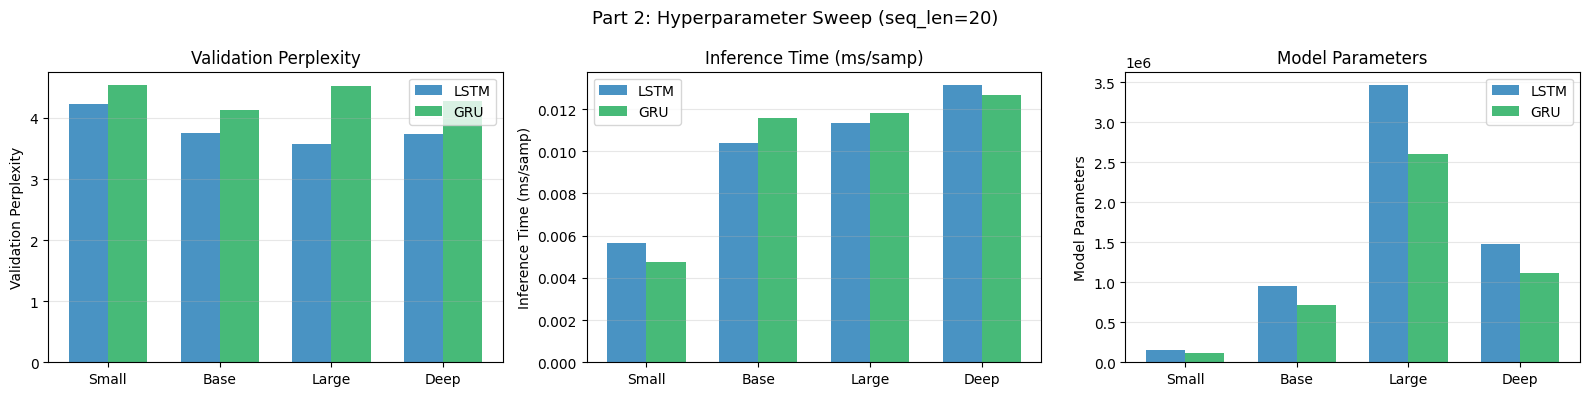

In [ ]:
# Part 2 plots: perplexity and inference time by config
labels     = [cfg['label'] for cfg in HP_CONFIGS]
x          = np.arange(len(labels))
width      = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Part 2: Hyperparameter Sweep (seq_len=20)', fontsize=13)

metrics = [
    ('val_ppl',  'Validation Perplexity',    'lower is better'),
    ('infer_ms', 'Inference Time (ms/samp)', 'lower is better'),
    ('params',   'Model Parameters',         'model complexity'),
]

for ax, (key, ylabel, note) in zip(axes, metrics):
    lstm_vals = [part2_results[('LSTM', l)][key] for l in labels]
    gru_vals  = [part2_results[('GRU',  l)][key] for l in labels]
    ax.bar(x - width/2, lstm_vals, width, label='LSTM', color='#2980b9', alpha=0.85)
    ax.bar(x + width/2, gru_vals,  width, label='GRU',  color='#27ae60', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('p2_part2_hp_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

BEST_CONFIG = dict(embed_dim=128, hidden_size=256, num_layers=2, dropout=0.3,
                   epochs=20, patience=5)

part3_results = {}

for mtype in ['LSTM', 'GRU']:
    print(f'\n=== {mtype} | seq_len=50 ===')
    history, elapsed, n_params, best_ep, infer_ms, model = train_model(
        mtype, 50, save_dir=SAVE_DIR, **BEST_CONFIG
    )
    part3_results[mtype] = {
        'history'   : history,
        'time_s'    : elapsed,
        'params'    : n_params,
        'best_ep'   : best_ep,
        'infer_ms'  : infer_ms,
        'train_loss': history['train_loss'][best_ep - 1],
        'val_loss'  : history['val_loss'][best_ep - 1],
        'val_acc'   : history['val_acc'][best_ep - 1],
        'val_ppl'   : history['val_ppl'][best_ep - 1],
    }
    print(f'  Done: {elapsed:.1f}s | params={n_params:,} | infer={infer_ms:.3f} ms/sample')


=== LSTM | seq_len=50 ===
  seq_len=50: 892,275 train | 223,069 val samples
  [LSTM | seq=50] Epoch  1 — train=1.7979  val=1.5069  acc=0.543  ppl=4.51  patience=0/5
  [LSTM | seq=50] Epoch  2 — train=1.5304  val=1.4240  acc=0.563  ppl=4.15  patience=0/5
  [LSTM | seq=50] Epoch  3 — train=1.4672  val=1.3852  acc=0.573  ppl=4.00  patience=0/5
  [LSTM | seq=50] Epoch  4 — train=1.4325  val=1.3641  acc=0.580  ppl=3.91  patience=0/5
  [LSTM | seq=50] Epoch  5 — train=1.4097  val=1.3511  acc=0.582  ppl=3.86  patience=0/5
  [LSTM | seq=50] Epoch  6 — train=1.3954  val=1.3401  acc=0.584  ppl=3.82  patience=0/5
  [LSTM | seq=50] Epoch  7 — train=1.3825  val=1.3297  acc=0.588  ppl=3.78  patience=0/5
  [LSTM | seq=50] Epoch  8 — train=1.3728  val=1.3251  acc=0.588  ppl=3.76  patience=0/5
  [LSTM | seq=50] Epoch  9 — train=1.3663  val=1.3186  acc=0.591  ppl=3.74  patience=0/5
  [LSTM | seq=50] Epoch 10 — train=1.3601  val=1.3139  acc=0.591  ppl=3.72  patience=0/5
  [LSTM | seq=50] Epoch 11 — trai

In [ ]:
# Part 3 — combined summary across all seq lengths
rows = []
for mtype in ['LSTM', 'GRU']:
    for slen, src in [(20, part1_results), (30, part1_results), (50, None)]:
        r = part3_results[mtype] if slen == 50 else src.get((mtype, slen))
        if r is None: continue
        rows.append({
            'Model'      : mtype,
            'Seq Len'    : slen,
            'Val Acc'    : f"{r['val_acc']:.3f}",
            'Perplexity' : f"{r['val_ppl']:.2f}",
            'Parameters' : f"{r['params']:,}",
            'Train Time' : f"{r['time_s']:.1f}s",
        })
df3 = pd.DataFrame(rows)
print('Part 3 — Sequence Length Comparison')
print(df3.to_string(index=False))
df3

=== Part 3 — Sequence Length Comparison ===
Model  Seq Len Val Acc Perplexity Parameters Train Time
 LSTM       20   0.590       3.75    946,625     728.5s
 LSTM       30   0.594       3.71    946,625     866.4s
 LSTM       50   0.596       3.67    946,625    1076.3s
  GRU       20   0.572       4.09    716,225     704.8s
  GRU       30   0.572       4.11    716,225     847.5s
  GRU       50   0.574       4.07    716,225    1045.2s


,Model,Seq Len,Val Acc,Perplexity,Parameters,Train Time
0,LSTM,20,0.590,3.75,"946,625",728.5s
1,LSTM,30,0.594,3.71,"946,625",866.4s
2,LSTM,50,0.596,3.67,"946,625",1076.3s
3,GRU,20,0.572,4.09,"716,225",704.8s
4,GRU,30,0.572,4.11,"716,225",847.5s
5,GRU,50,0.574,4.07,"716,225",1045.2s


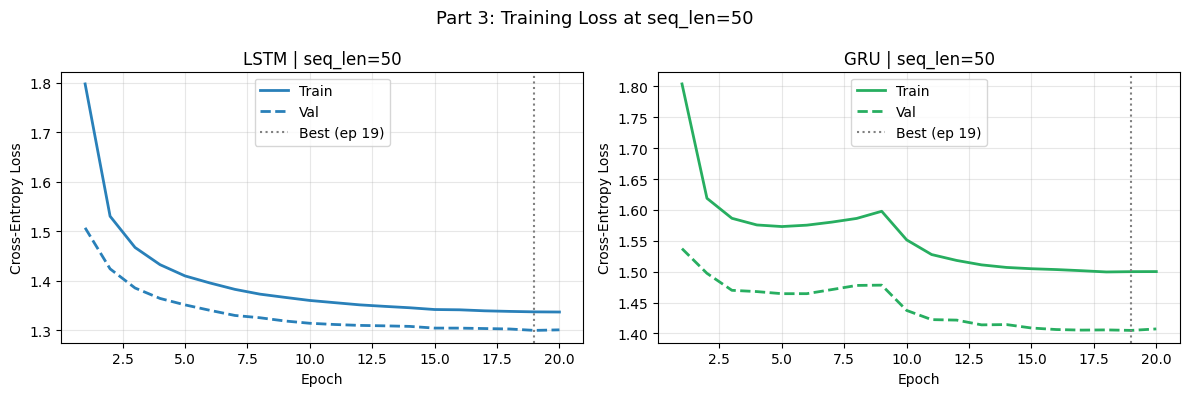

In [ ]:
# Part 3 loss curves for seq_len=50
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Part 3: Training Loss at seq_len=50', fontsize=13)

for ax, mtype in zip(axes, ['LSTM', 'GRU']):
    res = part3_results[mtype]
    ep  = range(1, len(res['history']['train_loss']) + 1)
    ax.plot(ep, res['history']['train_loss'], color=colors[mtype], linewidth=2, label='Train')
    ax.plot(ep, res['history']['val_loss'],   color=colors[mtype], linewidth=2, label='Val', linestyle='--')
    ax.axvline(res['best_ep'], color='gray', linestyle=':', linewidth=1.5, label=f"Best (ep {res['best_ep']})")
    ax.set_title(f'{mtype} | seq_len=50')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('p2_part3_seq50.png', dpi=150, bbox_inches='tight')
plt.show()